In [1]:
%matplotlib inline
import numpy as np
import torch

torch.set_printoptions(edgeitems=2, linewidth=75)

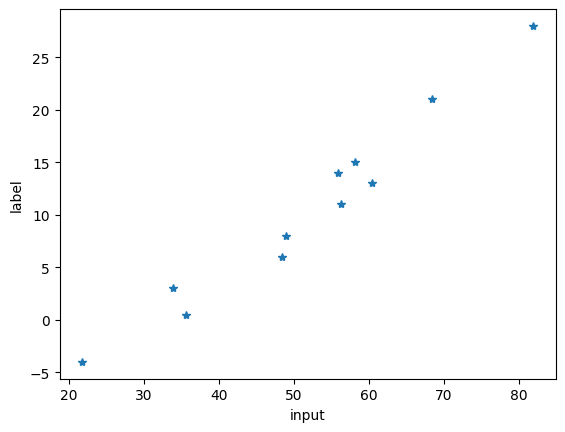

In [2]:
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]  # 输入
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]  # 标签值

t_u = torch.tensor(t_u)
t_un = 0.1 * t_u
t_c = torch.tensor(t_c)

from matplotlib import pyplot as plt

plt.plot(t_u.numpy(), t_c.numpy(), "*")
plt.xlabel("input")
plt.ylabel("label")
plt.show()

In [3]:
def model(t_u, w, b):
    return w * t_u + b


w = torch.ones(())
b = torch.zeros(())

print("w:", w)
print("w:", w.shape)
print("b:", b)
print("b:", b.shape)

t_p = model(t_u, w, b)
print("t_p:", t_p)
print("t_p:", t_p.shape)

w: tensor(1.)
w: torch.Size([])
b: tensor(0.)
b: torch.Size([])
t_p: tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])
t_p: torch.Size([11])


In [4]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c) ** 2
    return squared_diffs.mean()


loss = loss_fn(t_p, t_c)
print("loss:", loss)
print("loss:", loss.shape)

loss: tensor(1763.8848)
loss: torch.Size([])


In [5]:
import torch.optim as optim

dir(optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 'lr_scheduler',
 'swa_utils']

In [6]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-5
optimizer = optim.SGD([params], lr=learning_rate)

In [7]:
t_p = model(t_u, *params)
loss = loss_fn(t_p, t_c)
print("params:", params)
print("params.grad:", params.grad)

loss.backward()
print("params:", params)
print("params.grad:", params.grad)

optimizer.step()  # 更新参数
print("params:", params)
print("params.grad:", params.grad)

params: tensor([1., 0.], requires_grad=True)
params.grad: None
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([4517.2969,   82.6000])
params: tensor([ 9.5483e-01, -8.2600e-04], requires_grad=True)
params.grad: tensor([4517.2969,   82.6000])


In [9]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

t_p = model(t_un, *params)
loss = loss_fn(t_p, t_c)

# 如果我们在一个循环中调用前面的代码, 梯度就会在每次调用 backward() 时在叶节点中"累加", 那么我们的梯度下降就会遍布整个循环区域!
# 下面是准备循环的代码, 在适当的位置即在调用 backward() 之前对 zero_grad() 的调用.
print("params:", params)
print("params.grad:", params.grad)

loss.backward()
print("params:", params)
print("params.grad:", params.grad)  # 第一次的梯度

optimizer.step()  # 更新参数
print("params:", params)
print("params.grad:", params.grad)

# 强制将参数还原
with torch.no_grad():
    params[0] = 1.0
    params[1] = 0.0
print("params:", params)
print("params.grad:", params.grad)

# 再次执行正向传播
t_p = model(t_un, *params)
loss = loss_fn(t_p, t_c)
print("params:", params)
print("params.grad:", params.grad)  # 第一次的梯度

loss.backward()
print("params:", params)
print("params.grad:", params.grad)  # 第二次的梯度

optimizer.step()  # 更新参数
print("params:", params)
print("params.grad:", params.grad)  # 第二次的梯度

params: tensor([1., 0.], requires_grad=True)
params.grad: None
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1.7761, 0.1064], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([-155.2281,  -21.2800])
params: tensor([2.5523, 0.2128], requires_grad=True)
params.grad: tensor([-155.2281,  -21.2800])


In [10]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

t_p = model(t_un, *params)
loss = loss_fn(t_p, t_c)

# 如果我们在一个循环中调用前面的代码, 梯度就会在每次调用 backward() 时在叶节点中"累加", 那么我们的梯度下降就会遍布整个循环区域!
# 下面是准备循环的代码, 在适当的位置即在调用 backward() 之前对 zero_grad() 的调用.
print("params:", params)
print("params.grad:", params.grad)

loss.backward()
print("params:", params)
print("params.grad:", params.grad)  # 第一次的梯度

optimizer.step()  # 更新参数
print("params:", params)
print("params.grad:", params.grad)

# 强制将参数还原
with torch.no_grad():
    params[0] = 1.0
    params[1] = 0.0
print("params:", params)
print("params.grad:", params.grad)

# 再次执行正向传播
t_p = model(t_un, *params)
loss = loss_fn(t_p, t_c)
print("params:", params)
print("params.grad:", params.grad)  # 第一次的梯度

optimizer.zero_grad()  # 将梯度归零
loss.backward()
print("params:", params)
print("params.grad:", params.grad)  # 第一次的梯度

optimizer.step()  # 更新参数
print("params:", params)
print("params.grad:", params.grad)  # 第一次的梯度

params: tensor([1., 0.], requires_grad=True)
params.grad: None
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1.7761, 0.1064], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1., 0.], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])
params: tensor([1.7761, 0.1064], requires_grad=True)
params.grad: tensor([-77.6140, -10.6400])


In [11]:
def training_loop(n_epochs, optimizer, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print("Epoch %d, Loss %f" % (epoch, float(loss)))

    return params

In [12]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(n_epochs=5000, optimizer=optimizer, params=params, t_u=t_un, t_c=t_c)

Epoch 500, Loss 7.860120
Epoch 1000, Loss 3.828538
Epoch 1500, Loss 3.092191
Epoch 2000, Loss 2.957698
Epoch 2500, Loss 2.933134
Epoch 3000, Loss 2.928648
Epoch 3500, Loss 2.927830
Epoch 4000, Loss 2.927679
Epoch 4500, Loss 2.927652
Epoch 5000, Loss 2.927647


tensor([  5.3671, -17.3012], requires_grad=True)

In [13]:
# 使用 Adam 优化函数
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-1
optimizer = optim.Adam([params], lr=learning_rate)

training_loop(n_epochs=2000, optimizer=optimizer, params=params, t_u=t_u, t_c=t_c)

Epoch 500, Loss 7.612900
Epoch 1000, Loss 3.086698
Epoch 1500, Loss 2.928578
Epoch 2000, Loss 2.927646


tensor([  0.5367, -17.3021], requires_grad=True)

### 训练、验证和过拟合

In [14]:
print("t_u:", t_u)
print("t_u:", t_u.shape)

n_samples = t_u.shape[0]  # 数据集多少
print("n_samples:", n_samples)

n_val = int(0.2 * n_samples)  # 20% 用于验证
print("n_val:", n_val)

shuffled_indices = torch.randperm(n_samples)  # 打乱 0 - 10
print("shuffled_indices:", shuffled_indices)
print("shuffled_indices:", shuffled_indices.shape)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

print("train_indices:", train_indices)
print("train_indices:", train_indices.shape)
print("val_indices:", val_indices)
print("val_indices:", val_indices.shape)

t_u: tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000,
        21.8000, 48.4000, 60.4000, 68.4000])
t_u: torch.Size([11])
n_samples: 11
n_val: 2
shuffled_indices: tensor([ 0,  2,  9,  6,  7,  4,  3,  1,  5,  8, 10])
shuffled_indices: torch.Size([11])
train_indices: tensor([0, 2, 9, 6, 7, 4, 3, 1, 5])
train_indices: torch.Size([9])
val_indices: tensor([ 8, 10])
val_indices: torch.Size([2])


In [15]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

train_t_un = 0.1 * train_t_u
val_t_un = 0.1 * val_t_u

print("train_t_un:", train_t_un)
print("train_t_un:", train_t_un.shape)
print("train_t_c:", train_t_c)
print("train_t_c:", train_t_c.shape)

print("val_t_un:", val_t_un)
print("val_t_un:", val_t_un.shape)
print("val_t_c:", val_t_c)
print("val_t_c:", val_t_c.shape)

train_t_un: tensor([3.5700, 5.8200, 6.0400, 3.3900, 2.1800, 5.6300, 8.1900, 5.5900,
        4.8900])
train_t_un: torch.Size([9])
train_t_c: tensor([ 0.5000, 15.0000, 13.0000,  3.0000, -4.0000, 11.0000, 28.0000,
        14.0000,  8.0000])
train_t_c: torch.Size([9])
val_t_un: tensor([4.8400, 6.8400])
val_t_un: torch.Size([2])
val_t_c: tensor([ 6., 21.])
val_t_c: torch.Size([2])


In [16]:
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)

        val_t_p = model(val_t_u, *params)
        val_loss = loss_fn(val_t_p, val_t_c)

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if epoch <= 3 or epoch % 500 == 0:
            print(
                f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                f" Validation loss {val_loss.item():.4f}"
            )

    return params

In [17]:
params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
    n_epochs=3000,
    optimizer=optimizer,
    params=params,
    train_t_u=train_t_un,
    val_t_u=val_t_un,
    train_t_c=train_t_c,
    val_t_c=val_t_c,
)

Epoch 1, Training loss 75.7952, Validation loss 100.9256
Epoch 2, Training loss 38.2342, Validation loss 44.6465
Epoch 3, Training loss 31.5485, Validation loss 32.3576
Epoch 500, Training loss 6.4860, Validation loss 11.6878
Epoch 1000, Training loss 3.0221, Validation loss 7.4872
Epoch 1500, Training loss 2.5218, Validation loss 6.1733
Epoch 2000, Training loss 2.4496, Validation loss 5.7147
Epoch 2500, Training loss 2.4391, Validation loss 5.5463
Epoch 3000, Training loss 2.4376, Validation loss 5.4832


tensor([  5.2245, -16.4587], requires_grad=True)

In [18]:
def training_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        train_t_p = model(train_t_u, *params)
        train_loss = loss_fn(train_t_p, train_t_c)

        # PyTorch 允许我们在不需要的时候关闭自动求导, 使用上下文管理器 torch.no_grad().
        with torch.no_grad():
            val_t_p = model(val_t_u, *params)
            val_loss = loss_fn(val_t_p, val_t_c)
            assert val_loss.requires_grad == False

        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if epoch <= 3 or epoch % 500 == 0:
            print(
                f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                f" Validation loss {val_loss.item():.4f}"
            )
    return params


params = torch.tensor([1.0, 0.0], requires_grad=True)
learning_rate = 1e-2
optimizer = optim.SGD([params], lr=learning_rate)

training_loop(
    n_epochs=3000,
    optimizer=optimizer,
    params=params,
    train_t_u=train_t_un,
    val_t_u=val_t_un,
    train_t_c=train_t_c,
    val_t_c=val_t_c,
)

Epoch 1, Training loss 75.7952, Validation loss 100.9256
Epoch 2, Training loss 38.2342, Validation loss 44.6465
Epoch 3, Training loss 31.5485, Validation loss 32.3576
Epoch 500, Training loss 6.4860, Validation loss 11.6878
Epoch 1000, Training loss 3.0221, Validation loss 7.4872
Epoch 1500, Training loss 2.5218, Validation loss 6.1733
Epoch 2000, Training loss 2.4496, Validation loss 5.7147
Epoch 2500, Training loss 2.4391, Validation loss 5.5463
Epoch 3000, Training loss 2.4376, Validation loss 5.4832


tensor([  5.2245, -16.4587], requires_grad=True)

In [19]:
# 使用相关的 set_grad_enabled(), 我们还可以根据一个布尔表达式设定代码运行时启用或禁用自动求导的条件,
# 典型的条件是我们是在训练模式还是推理模式下运行
def calc_forward(t_u, t_c, is_train):
    with torch.set_grad_enabled(is_train):
        t_p = model(t_u, *params)
        loss = loss_fn(t_p, t_c)
    return loss


calc_forward(train_t_un, train_t_c, False)

tensor(2.4376)